## Compute Octiles for XLK

In [1]:
# Table 20 style: XLK overnight (CO) and daytime (OC) return octiles by year (1999–2025)
# Octiles: O_i = quantile(R, i/8) for i = 1,…,7 (12.5% … 87.5%)
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path(".")
YEAR_LO, YEAR_HI = 1999, 2025


def _load_spy(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for c in ["Close", "High", "Low", "Open"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(subset=["Date", "Close", "Open"]).sort_values("Date")


def _add_co_oc_returns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    c_prev = out["Close"].shift(1)
    out["R_CO"] = (out["Open"] - c_prev) / c_prev  # overnight, main.tex
    out["R_OC"] = (out["Close"] - out["Open"]) / out["Open"]  # daytime
    out["year"] = out["Date"].dt.year
    return out.dropna(subset=["R_CO", "R_OC"])


def _seven_octiles(x: np.ndarray) -> list[float]:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 8:
        return [np.nan] * 7
    return [float(np.quantile(x, i / 8.0)) for i in range(1, 8)]


def _true_mad(x: np.ndarray) -> float:
    """Empirical MAD = mean(|x - median(x)|); reference for %Err on quadrature H."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    return float(np.mean(np.abs(x - med)))


spy = _add_co_oc_returns(_load_spy(DATA_DIR / "XLK.csv"))
spy = spy[(spy["year"] >= YEAR_LO) & (spy["year"] <= YEAR_HI)]

rows: list[dict] = []
for yr in range(YEAR_LO, YEAR_HI + 1):
    g = spy.loc[spy["year"] == yr]
    if g.empty:
        continue
    co = _seven_octiles(g["R_CO"].to_numpy())
    oc = _seven_octiles(g["R_OC"].to_numpy())
    row = {"Year": int(yr), "n": int(len(g))}
    for i, v in enumerate(co, start=1):
        row[f"overnight_O{i}"] = v
    for i, v in enumerate(oc, start=1):
        row[f"daytime_O{i}"] = v
    rows.append(row)

col_on = [f"overnight_O{i}" for i in range(1, 8)]
col_dy = [f"daytime_O{i}" for i in range(1, 8)]
xlk_yearly_octiles = pd.DataFrame(rows)[["Year", "n"] + col_on + col_dy]

true_rows: list[dict] = []
for yr in range(YEAR_LO, YEAR_HI + 1):
    g = spy.loc[spy["year"] == yr]
    if g.empty:
        continue
    true_rows.append(
        {
            "Year": int(yr),
            "H_true_CO": _true_mad(g["R_CO"].to_numpy()),
            "H_true_OC": _true_mad(g["R_OC"].to_numpy()),
        }
    )
xlk_yearly_true_mad = pd.DataFrame(true_rows)

out_path = DATA_DIR / "XLK_Octiles.csv"
xlk_yearly_octiles.to_csv(out_path, index=False)
print(f"Saved {out_path.resolve()}\n")

# Preview (same layout as paper table: Year | 7 overnight octiles | 7 daytime octiles)
preview = xlk_yearly_octiles.drop(columns=["n"])
with pd.option_context("display.max_rows", None, "display.width", 200):
    print(preview.to_string(index=False, float_format=lambda v: f"{v * 100: .3f}"))


Saved /Users/tripa/Desktop/Projects/MAD/XLK_Octiles.csv

 Year  overnight_O1  overnight_O2  overnight_O3  overnight_O4  overnight_O5  overnight_O6  overnight_O7  daytime_O1  daytime_O2  daytime_O3  daytime_O4  daytime_O5  daytime_O6  daytime_O7
 1999        -0.523        -0.180         0.057         0.436         0.684         1.065         1.528      -1.951      -1.309      -0.542      -0.037       0.414       0.922       1.557
 2000        -1.257        -0.583        -0.170         0.118         0.460         0.888         1.521      -2.716      -1.995      -0.962      -0.351       0.402       1.215       2.133
 2001        -1.630        -0.961        -0.449        -0.051         0.339         0.771         1.654      -2.596      -1.569      -0.745      -0.101       0.510       1.311       2.735
 2002        -1.621        -1.072        -0.530        -0.051         0.365         0.898         1.480      -2.661      -1.696      -1.226      -0.429       0.613       1.377       2.710
 20

## Use the octiles to calculate daytime & overnight

In [2]:
# Table 21 style: C-trapezoid MAD $H$, skewness $G$, kurtosis $K$ for each year and sub-period (CO / OC)
# Builds on `xlk_yearly_octiles` from the previous cell (same $O_1,\ldots,O_7$).
#
# **main.tex:** $I_L$, $I_R$ as eq.~(875)--(876); $H=I_R-I_L$, $\mu=I_L+I_R$ (Table `tab:quadrature_mad`, C-Trapezoid).
# **$G$:** eq.~(1614) $G=(\mu-O_4)/H$ with those $\mu,H$ (Table `tab:skewness` Exact row with quadrature subareas).
# **$K$:** Table `tab:kurtosis` C-Trapezoid (Moore-type octile ratio), scaled by $\tfrac{1}{2}$ so $K\in[0,1]$: $\displaystyle K=\frac{1}{2}\cdot\frac{6(O_7-O_1)-6(O_6-O_2)+2(O_5-O_3)}{3(O_7-O_1)-2(O_6-O_2)+3(O_5-O_3)}$.
# **$O_4/H$:** median octile divided by the same $H$ as above (columns `O4_H_CO`, `O4_H_OC`).

from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path(".")


def c_trapezoid_H_G_K(
    o1: float, o2: float, o3: float, o4: float, o5: float, o6: float, o7: float
) -> tuple[float, float, float]:
    o = np.array([o1, o2, o3, o4, o5, o6, o7], dtype=float)
    if not np.all(np.isfinite(o)):
        return np.nan, np.nan, np.nan
    i_l = (3.0 * o1 - 2.0 * o2 + 3.0 * o3) / 8.0
    i_r = (3.0 * o5 - 2.0 * o6 + 3.0 * o7) / 8.0
    mu = i_l + i_r
    h = i_r - i_l
    den_k = 3.0 * (o7 - o1) - 2.0 * (o6 - o2) + 3.0 * (o5 - o3)
    if abs(h) < 1e-15 or abs(den_k) < 1e-15:
        return float(h), np.nan, np.nan
    g = (mu - o4) / h
    num_k = 6.0 * (o7 - o1) - 6.0 * (o6 - o2) + 2.0 * (o5 - o3)
    k = (num_k / den_k) / 2.0
    return float(h), float(g), float(k)


if "xlk_yearly_octiles" not in globals():
    raise RuntimeError("Run the previous cell first so `xlk_yearly_octiles` is defined.")
if "xlk_yearly_true_mad" not in globals():
    raise RuntimeError("Run the octiles cell first so `xlk_yearly_true_mad` is defined.")


def _pct_err_mad(est: np.ndarray, true_val: np.ndarray) -> np.ndarray:
    """Same as dataset.ipynb: 100 * (est - true) / |true| when |true| is large enough."""
    est = np.asarray(est, dtype=float)
    tv = np.asarray(true_val, dtype=float)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(
            np.isfinite(est) & np.isfinite(tv) & (np.abs(tv) >= 1e-12),
            100.0 * (est - tv) / np.abs(tv),
            np.nan,
        )


def _o4_over_h(o4: float, h: float) -> float:
    """Median octile divided by MAD $H$ (same units as $O_4$ and $H$)."""
    if not (np.isfinite(o4) and np.isfinite(h)) or abs(h) < 1e-15:
        return float("nan")
    return float(o4 / h)


out_rows: list[dict] = []
for _, r in xlk_yearly_octiles.iterrows():
    yr = int(r["Year"])
    o4_co = float(r["overnight_O4"])
    o4_oc = float(r["daytime_O4"])
    h_co, g_co, k_co = c_trapezoid_H_G_K(
        *[r[f"overnight_O{i}"] for i in range(1, 8)]
    )
    h_oc, g_oc, k_oc = c_trapezoid_H_G_K(
        *[r[f"daytime_O{i}"] for i in range(1, 8)]
    )
    out_rows.append(
        {
            "Year": yr,
            "H_CO": h_co,
            "O4_H_CO": _o4_over_h(o4_co, h_co),
            "G_CO": g_co,
            "K_CO": k_co,
            "H_OC": h_oc,
            "O4_H_OC": _o4_over_h(o4_oc, h_oc),
            "G_OC": g_oc,
            "K_OC": k_oc,
        }
    )

spy_yearly_mad_ct = pd.DataFrame(out_rows).sort_values("Year").reset_index(drop=True)
spy_yearly_mad_ct = spy_yearly_mad_ct.merge(xlk_yearly_true_mad, on="Year", how="left")
spy_yearly_mad_ct["%Err MAD_CO"] = _pct_err_mad(
    spy_yearly_mad_ct["H_CO"].to_numpy(), spy_yearly_mad_ct["H_true_CO"].to_numpy()
)
spy_yearly_mad_ct["%Err MAD_OC"] = _pct_err_mad(
    spy_yearly_mad_ct["H_OC"].to_numpy(), spy_yearly_mad_ct["H_true_OC"].to_numpy()
)
spy_yearly_mad_ct = spy_yearly_mad_ct.drop(columns=["H_true_CO", "H_true_OC"])

csv_metrics = DATA_DIR / "XLK_Return_Metrics.csv"
spy_yearly_mad_ct.to_csv(csv_metrics, index=False)
print(f"Saved {csv_metrics.resolve()}\n")

# Preview matching Table 21 layout: Year | H^CO, O4/H^CO, G^CO, K^CO | H^OC, O4/H^OC, G^OC, K^OC
show = spy_yearly_mad_ct.copy()
# Display H in percent; keep G, K, and O4/H dimensionless.
for col in ["H_CO", "H_OC"]:
    if col in show.columns:
        show[col] = show[col] * 100.0

with pd.option_context("display.max_rows", None, "display.width", 120):
    print(
        show.to_string(
            index=False,
            float_format=lambda v: f"{v: .3f}" if isinstance(v, float) else str(v),
        )
    )


Saved /Users/tripa/Desktop/Projects/MAD/XLK_Return_Metrics.csv

 Year   H_CO  O4_H_CO   G_CO   K_CO   H_OC  O4_H_OC   G_OC   K_OC  %Err MAD_CO  %Err MAD_OC
 1999  0.693    0.629 -0.003  0.549  1.116   -0.033 -0.056  0.536      -14.621      -12.777
 2000  0.910    0.129  0.015  0.625  1.527   -0.230  0.076  0.514      -18.435      -11.622
 2001  1.095   -0.046  0.060  0.622  1.750   -0.058  0.074  0.615       -9.617       -3.409
 2002  1.006   -0.051 -0.020  0.533  1.936   -0.222  0.154  0.564      -16.723        3.759
 2003  0.653    0.210 -0.043  0.636  1.011    0.000 -0.030  0.576       -4.915      -10.046
 2004  0.461    0.000  0.008  0.576  0.697    0.074 -0.081  0.603      -12.050       -6.682
 2005  0.287    0.171  0.000  0.626  0.540   -0.095 -0.032  0.519      -16.578      -11.757
 2006  0.343    0.000  0.090  0.579  0.605    0.080 -0.028  0.566      -15.225      -11.303
 2007  0.481    0.163  0.081  0.607  0.589    0.128 -0.161  0.614      -14.047      -10.855
 2008  0.986    

In [3]:
# Table 21 style (midpoint quadrature): MAD $H$, skewness $G$, kurtosis $K$ for CO / OC
# Uses the same `xlk_yearly_octiles` as the C-trapezoid cell.
#
# **main.tex** § Midpoint / Table `tab:left_right_subareas`: $I_L \approx O_2/2$, $I_R \approx O_6/2$,
# hence $\mu \approx (O_2+O_6)/2$, $H \approx (O_6-O_2)/2$ (Table `tab:quadrature_mad`, Midpoint).
# **$G$:** Table `tab:skewness` Midpoint (Galton skewness in octile form):
#   $((O_6-O_4)-(O_4-O_2))/(O_6-O_2)$, equivalently $(\mu-O_4)/H$ with midpoint $\mu,H$.
# **$K$:** Table `tab:kurtosis` Midpoint (Moore octile kurtosis):
#   $((O_7-O_1)-(O_5-O_3))/(4(O_6-O_2))$ (same $\tfrac{1}{2}$ scaling as C-trapezoid for $K\in[0,1]$).
# **$O_4/H$:** $O_4$ divided by midpoint $H=(O_6-O_2)/2$ (columns `O4_H_CO`, `O4_H_OC`).

from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path(".")


def midpoint_H_G_K(
    o1: float, o2: float, o3: float, o4: float, o5: float, o6: float, o7: float
) -> tuple[float, float, float]:
    o = np.array([o1, o2, o3, o4, o5, o6, o7], dtype=float)
    if not np.all(np.isfinite(o)):
        return np.nan, np.nan, np.nan
    mu = (o2 + o6) / 2.0
    h = (o6 - o2) / 2.0
    if abs(h) < 1e-15:
        return float(h), np.nan, np.nan
    g = (mu - o4) / h
    k = ((o7 - o1) - (o5 - o3)) / (4.0 * (o6 - o2))
    return float(h), float(g), float(k)


if "xlk_yearly_octiles" not in globals():
    raise RuntimeError("Run the octiles cell first so `xlk_yearly_octiles` is defined.")
if "xlk_yearly_true_mad" not in globals():
    raise RuntimeError("Run the octiles cell first so `xlk_yearly_true_mad` is defined.")


def _pct_err_mad(est: np.ndarray, true_val: np.ndarray) -> np.ndarray:
    est = np.asarray(est, dtype=float)
    tv = np.asarray(true_val, dtype=float)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(
            np.isfinite(est) & np.isfinite(tv) & (np.abs(tv) >= 1e-12),
            100.0 * (est - tv) / np.abs(tv),
            np.nan,
        )


def _o4_over_h(o4: float, h: float) -> float:
    """Median octile divided by MAD $H$ (same units as $O_4$ and $H$)."""
    if not (np.isfinite(o4) and np.isfinite(h)) or abs(h) < 1e-15:
        return float("nan")
    return float(o4 / h)


rows_mid: list[dict] = []
for _, r in xlk_yearly_octiles.iterrows():
    yr = int(r["Year"])
    o4_co = float(r["overnight_O4"])
    o4_oc = float(r["daytime_O4"])
    h_co, g_co, k_co = midpoint_H_G_K(
        *[r[f"overnight_O{i}"] for i in range(1, 8)]
    )
    h_oc, g_oc, k_oc = midpoint_H_G_K(
        *[r[f"daytime_O{i}"] for i in range(1, 8)]
    )
    rows_mid.append(
        {
            "Year": yr,
            "H_CO": h_co,
            "O4_H_CO": _o4_over_h(o4_co, h_co),
            "G_CO": g_co,
            "K_CO": k_co,
            "H_OC": h_oc,
            "O4_H_OC": _o4_over_h(o4_oc, h_oc),
            "G_OC": g_oc,
            "K_OC": k_oc,
        }
    )

spy_yearly_mad_mid = pd.DataFrame(rows_mid).sort_values("Year").reset_index(drop=True)
spy_yearly_mad_mid = spy_yearly_mad_mid.merge(xlk_yearly_true_mad, on="Year", how="left")
spy_yearly_mad_mid["%Err MAD_CO"] = _pct_err_mad(
    spy_yearly_mad_mid["H_CO"].to_numpy(), spy_yearly_mad_mid["H_true_CO"].to_numpy()
)
spy_yearly_mad_mid["%Err MAD_OC"] = _pct_err_mad(
    spy_yearly_mad_mid["H_OC"].to_numpy(), spy_yearly_mad_mid["H_true_OC"].to_numpy()
)
spy_yearly_mad_mid = spy_yearly_mad_mid.drop(columns=["H_true_CO", "H_true_OC"])

csv_mid = DATA_DIR / "XLK_Return_Metrics_midpoint.csv"
spy_yearly_mad_mid.to_csv(csv_mid, index=False)
print(f"Saved {csv_mid.resolve()}\n")

show_mid = spy_yearly_mad_mid.copy()
# Display H in percent; keep G, K, and O4/H dimensionless.
for col in ["H_CO", "H_OC"]:
    if col in show_mid.columns:
        show_mid[col] = show_mid[col] * 100.0

with pd.option_context("display.max_rows", None, "display.width", 120):
    print(
        show_mid.to_string(
            index=False,
            float_format=lambda v: f"{v: .3f}" if isinstance(v, float) else str(v),
        )
    )


Saved /Users/tripa/Desktop/Projects/MAD/XLK_Return_Metrics_midpoint.csv

 Year   H_CO  O4_H_CO   G_CO   K_CO   H_OC  O4_H_OC   G_OC   K_OC  %Err MAD_CO  %Err MAD_OC
 1999  0.622    0.701  0.010  0.286  1.116   -0.033 -0.140  0.286      -23.366      -12.792
 2000  0.736    0.160  0.047  0.365  1.605   -0.218 -0.025  0.271      -34.095       -7.142
 2001  0.866   -0.059 -0.051  0.360  1.440   -0.070 -0.019  0.354      -28.509      -20.511
 2002  0.985   -0.052 -0.036  0.280  1.537   -0.279  0.176  0.287      -18.448      -17.627
 2003  0.488    0.282 -0.019  0.375  0.930    0.000  0.065  0.318      -28.948      -17.258
 2004  0.423    0.000  0.092  0.317  0.588    0.087 -0.072  0.342      -19.338      -21.276
 2005  0.229    0.215 -0.070  0.366  0.546   -0.093  0.098  0.271      -33.548      -10.704
 2006  0.319    0.000  0.100  0.322  0.606    0.080 -0.057  0.317      -21.215      -11.137
 2007  0.400    0.196 -0.015  0.344  0.508    0.148 -0.075  0.355      -28.489      -23.163
 2008  

## Skewness \(G\) and kurtosis \(K\) vs year (overnight vs daytime)


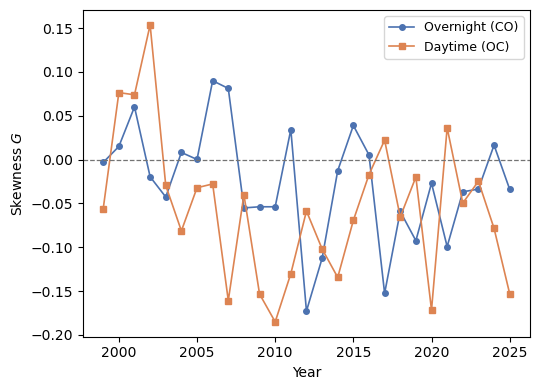

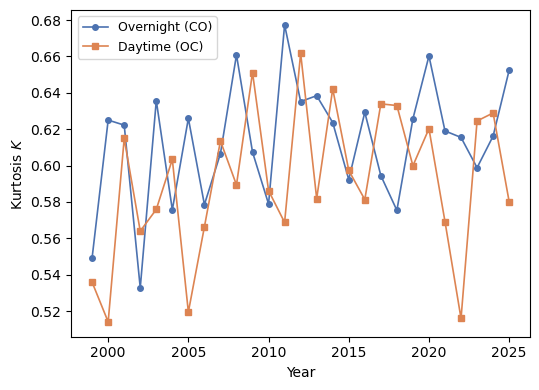

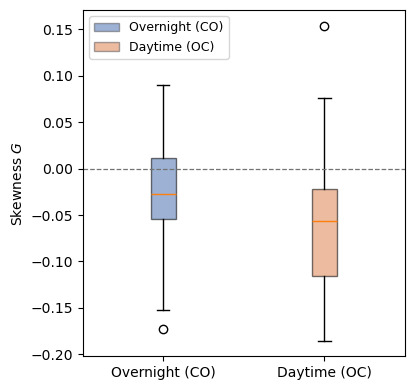

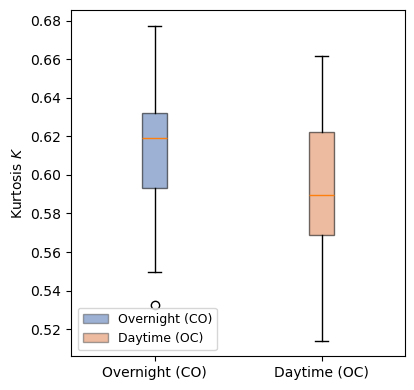

Saved /Users/tripa/Desktop/Projects/MAD/XLK_line_G.jpg
Saved /Users/tripa/Desktop/Projects/MAD/XLK_line_K.jpg
Saved /Users/tripa/Desktop/Projects/MAD/XLK_boxplot_G.jpg
Saved /Users/tripa/Desktop/Projects/MAD/XLK_boxplot_K.jpg


In [4]:
# G and K vs year (lines) + box plots across years — C-trapezoid XLK (one metric per saved image)
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

DATA_DIR = Path(".")
METRICS = DATA_DIR / "XLK_Return_Metrics.csv"

if "spy_yearly_mad_ct" in globals() and len(spy_yearly_mad_ct) > 0:
    plot_df = spy_yearly_mad_ct[["Year", "G_CO", "G_OC", "K_CO", "K_OC"]].copy()
else:
    plot_df = pd.read_csv(METRICS)[["Year", "G_CO", "G_OC", "K_CO", "K_OC"]]

plot_df = plot_df.loc[plot_df["Year"] >= 1999].copy()

t = plot_df["Year"].to_numpy()
colors = ("#4C72B0", "#DD8452")  # overnight, daytime

_SAVE_KW = {"dpi": 220, "bbox_inches": "tight"}

# --- Time series: $G$ ---
fig, axg = plt.subplots(figsize=(5.5, 4))
axg.plot(t, plot_df["G_CO"], "-o", ms=4, lw=1.2, label="Overnight (CO)", color=colors[0])
axg.plot(t, plot_df["G_OC"], "-s", ms=4, lw=1.2, label="Daytime (OC)", color=colors[1])
axg.axhline(0, color="0.45", lw=0.9, ls="--")
axg.set_xlabel("Year")
axg.set_ylabel(r"Skewness $G$")
axg.legend(loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(DATA_DIR / "XLK_line_G.jpg", **_SAVE_KW)
plt.show()

# --- Time series: $K$ ---
fig, axk = plt.subplots(figsize=(5.5, 4))
axk.plot(t, plot_df["K_CO"], "-o", ms=4, lw=1.2, label="Overnight (CO)", color=colors[0])
axk.plot(t, plot_df["K_OC"], "-s", ms=4, lw=1.2, label="Daytime (OC)", color=colors[1])
axk.set_xlabel("Year")
axk.set_ylabel(r"Kurtosis $K$")
axk.legend(loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(DATA_DIR / "XLK_line_K.jpg", **_SAVE_KW)
plt.show()

# --- Box plots ---
data_g = [plot_df["G_CO"].dropna(), plot_df["G_OC"].dropna()]
data_k = [plot_df["K_CO"].dropna(), plot_df["K_OC"].dropna()]
_lbl = ["Overnight (CO)", "Daytime (OC)"]

fig, ax = plt.subplots(figsize=(4.25, 4))
try:
    bp_g = ax.boxplot(data_g, tick_labels=_lbl, patch_artist=True)
except TypeError:
    bp_g = ax.boxplot(data_g, labels=_lbl, patch_artist=True)
for patch, c in zip(bp_g["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.55)
ax.axhline(0, color="0.45", lw=0.9, ls="--")
ax.set_ylabel(r"Skewness $G$")
ax.legend(
    handles=[
        Patch(facecolor=colors[0], edgecolor="0.35", alpha=0.55, label=_lbl[0]),
        Patch(facecolor=colors[1], edgecolor="0.35", alpha=0.55, label=_lbl[1]),
    ],
    loc="best",
    fontsize=9,
)
plt.tight_layout()
fig.savefig(DATA_DIR / "XLK_boxplot_G.jpg", **_SAVE_KW)
plt.show()

fig, ax = plt.subplots(figsize=(4.25, 4))
try:
    bp_k = ax.boxplot(data_k, tick_labels=_lbl, patch_artist=True)
except TypeError:
    bp_k = ax.boxplot(data_k, labels=_lbl, patch_artist=True)
for patch, c in zip(bp_k["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.55)
ax.set_ylabel(r"Kurtosis $K$")
ax.legend(
    handles=[
        Patch(facecolor=colors[0], edgecolor="0.35", alpha=0.55, label=_lbl[0]),
        Patch(facecolor=colors[1], edgecolor="0.35", alpha=0.55, label=_lbl[1]),
    ],
    loc="best",
    fontsize=9,
)
plt.tight_layout()
fig.savefig(DATA_DIR / "XLK_boxplot_K.jpg", **_SAVE_KW)
plt.show()

for name in (
    "XLK_line_G.jpg",
    "XLK_line_K.jpg",
    "XLK_boxplot_G.jpg",
    "XLK_boxplot_K.jpg",
):
    print(f"Saved {(DATA_DIR / name).resolve()}")


## $O_4/H$ vs year (overnight vs daytime), C-trapezoid XLK

Columns `O4_H_CO`, `O4_H_OC` in `XLK_Return_Metrics.csv` (from `spy_yearly_mad_ct` after running the Table 21 cell).

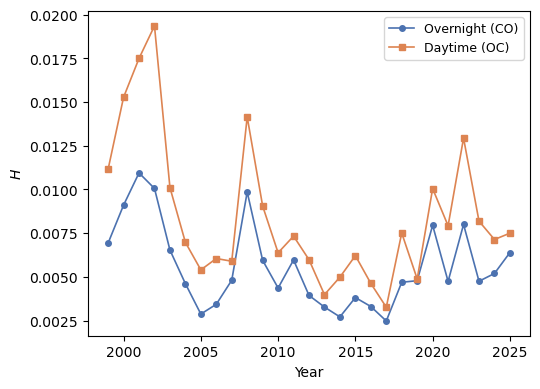

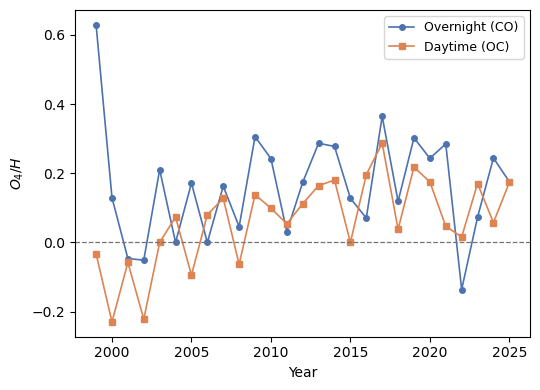

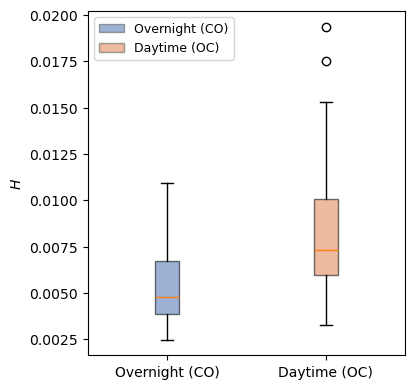

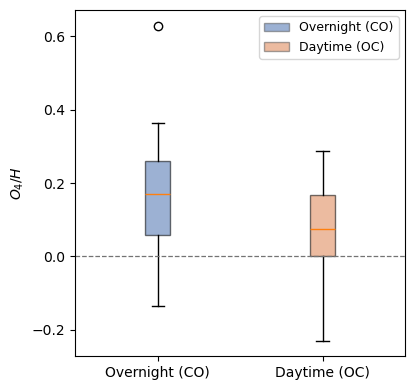

Saved /Users/tripa/Desktop/Projects/MAD/XLK_line_H.jpg
Saved /Users/tripa/Desktop/Projects/MAD/XLK_line_O4H.jpg
Saved /Users/tripa/Desktop/Projects/MAD/XLK_boxplot_H.jpg
Saved /Users/tripa/Desktop/Projects/MAD/XLK_boxplot_O4H.jpg


In [5]:
# $H$ and $O_4/H$ vs year (line) + box plots — C-trapezoid XLK (one metric per saved image).

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

DATA_DIR = Path(".")
METRICS = DATA_DIR / "XLK_Return_Metrics.csv"

if "spy_yearly_mad_ct" in globals() and len(spy_yearly_mad_ct) > 0:
    plot_df = spy_yearly_mad_ct[
        ["Year", "H_CO", "H_OC", "O4_H_CO", "O4_H_OC"]
    ].copy()
else:
    plot_df = pd.read_csv(METRICS)[
        ["Year", "H_CO", "H_OC", "O4_H_CO", "O4_H_OC"]
    ]

plot_df = plot_df.loc[plot_df["Year"] >= 1999].copy()
t = plot_df["Year"].to_numpy()
colors = ("#4C72B0", "#DD8452")  # overnight, daytime

_SAVE_KW = {"dpi": 220, "bbox_inches": "tight"}

# --- Time series ---
for y1, y2, ylab, fname, zline in (
    (
        plot_df["H_CO"],
        plot_df["H_OC"],
        r"$H$",
        "XLK_line_H.jpg",
        False,
    ),
    (
        plot_df["O4_H_CO"],
        plot_df["O4_H_OC"],
        r"$O_4/H$",
        "XLK_line_O4H.jpg",
        True,
    ),
):
    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.plot(t, y1, "-o", ms=4, lw=1.2, label="Overnight (CO)", color=colors[0])
    ax.plot(t, y2, "-s", ms=4, lw=1.2, label="Daytime (OC)", color=colors[1])
    ax.set_ylabel(ylab)
    ax.set_xlabel("Year")
    ax.legend(loc="best", fontsize=9)
    if zline:
        ax.axhline(0, color="0.45", lw=0.9, ls="--")
    plt.tight_layout()
    fig.savefig(DATA_DIR / fname, **_SAVE_KW)
    plt.show()

# --- Box plots ---
_lbl = ["Overnight (CO)", "Daytime (OC)"]
for data, ylab, fname, zline in (
    (
        [plot_df["H_CO"].dropna(), plot_df["H_OC"].dropna()],
        r"$H$",
        "XLK_boxplot_H.jpg",
        False,
    ),
    (
        [plot_df["O4_H_CO"].dropna(), plot_df["O4_H_OC"].dropna()],
        r"$O_4/H$",
        "XLK_boxplot_O4H.jpg",
        True,
    ),
):
    fig, ax = plt.subplots(figsize=(4.25, 4))
    try:
        bp = ax.boxplot(data, tick_labels=_lbl, patch_artist=True)
    except TypeError:
        bp = ax.boxplot(data, labels=_lbl, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_ylabel(ylab)
    ax.legend(
        handles=[
            Patch(facecolor=colors[0], edgecolor="0.35", alpha=0.55, label=_lbl[0]),
            Patch(facecolor=colors[1], edgecolor="0.35", alpha=0.55, label=_lbl[1]),
        ],
        loc="best",
        fontsize=9,
    )
    if zline:
        ax.axhline(0, color="0.45", lw=0.9, ls="--")
    plt.tight_layout()
    fig.savefig(DATA_DIR / fname, **_SAVE_KW)
    plt.show()

for name in (
    "XLK_line_H.jpg",
    "XLK_line_O4H.jpg",
    "XLK_boxplot_H.jpg",
    "XLK_boxplot_O4H.jpg",
):
    print(f"Saved {(DATA_DIR / name).resolve()}")


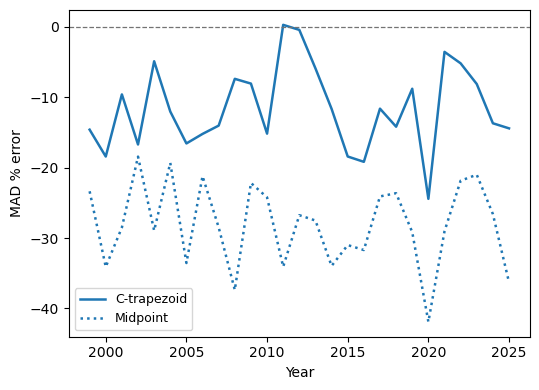

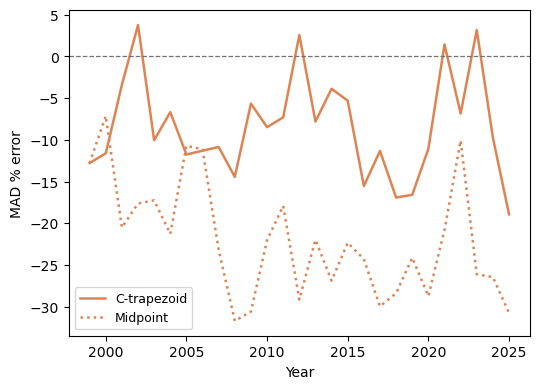

Saved /Users/tripa/Desktop/Projects/MAD/XLK_MAD_pct_err_CO.jpg
Saved /Users/tripa/Desktop/Projects/MAD/XLK_MAD_pct_err_OC.jpg


In [6]:
# MAD % error vs year: C-trapezoid (solid) vs midpoint (dotted) — one session per saved image
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path(".")
METRICS_CT = DATA_DIR / "XLK_Return_Metrics.csv"
METRICS_MID = DATA_DIR / "XLK_Return_Metrics_midpoint.csv"

if "spy_yearly_mad_ct" in globals() and len(spy_yearly_mad_ct) > 0:
    ct_df = spy_yearly_mad_ct[["Year", "%Err MAD_CO", "%Err MAD_OC"]].copy()
else:
    ct_df = pd.read_csv(METRICS_CT)[["Year", "%Err MAD_CO", "%Err MAD_OC"]]

if "spy_yearly_mad_mid" in globals() and len(spy_yearly_mad_mid) > 0:
    mid_df = spy_yearly_mad_mid[["Year", "%Err MAD_CO", "%Err MAD_OC"]].copy()
else:
    mid_df = pd.read_csv(METRICS_MID)[["Year", "%Err MAD_CO", "%Err MAD_OC"]]

plot_df = ct_df.merge(mid_df, on="Year", suffixes=("_CT", "_MID")).sort_values("Year")
plot_df = plot_df.loc[plot_df["Year"] >= 1999].copy()

t = plot_df["Year"].to_numpy()

_SAVE_KW = {"dpi": 220, "bbox_inches": "tight"}

# Overnight (CO)
fig, ax_co = plt.subplots(figsize=(5.5, 4))
ax_co.plot(t, plot_df["%Err MAD_CO_CT"], color="#1f77b4", lw=1.8, ls="-", label="C-trapezoid")
ax_co.plot(t, plot_df["%Err MAD_CO_MID"], color="#1f77b4", lw=1.8, ls=":", label="Midpoint")
ax_co.axhline(0, color="0.45", lw=0.9, ls="--")
ax_co.set_xlabel("Year")
ax_co.set_ylabel("MAD % error")
ax_co.legend(loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(DATA_DIR / "XLK_MAD_pct_err_CO.jpg", **_SAVE_KW)
plt.show()

# Daytime (OC)
fig, ax_oc = plt.subplots(figsize=(5.5, 4))
ax_oc.plot(t, plot_df["%Err MAD_OC_CT"], color="#DD8452", lw=1.8, ls="-", label="C-trapezoid")
ax_oc.plot(t, plot_df["%Err MAD_OC_MID"], color="#DD8452", lw=1.8, ls=":", label="Midpoint")
ax_oc.axhline(0, color="0.45", lw=0.9, ls="--")
ax_oc.set_xlabel("Year")
ax_oc.set_ylabel("MAD % error")
ax_oc.legend(loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(DATA_DIR / "XLK_MAD_pct_err_OC.jpg", **_SAVE_KW)
plt.show()

for name in ("XLK_MAD_pct_err_CO.jpg", "XLK_MAD_pct_err_OC.jpg"):
    print(f"Saved {(DATA_DIR / name).resolve()}")


In [7]:
# Tables for main.tex (lines 1933-1990): skewness G and kurtosis K approximation errors
# using n=100 quantile points per distribution.

import numpy as np
import pandas as pd
from scipy import stats

n = 100  # requested sample size / grid size
n_true = 200_000  # dense grid for near-true benchmark metrics


def octiles_from_points(x: np.ndarray) -> dict:
    q = np.quantile(x, [i / 8 for i in range(1, 8)], method="linear")
    return {i: float(q[i - 1]) for i in range(1, 8)}


def true_H_G_K_from_points(x: np.ndarray) -> tuple[float, float, float]:
    # True metrics follow the paper definitions around octiles:
    # H = E|X-O4|, G = (H(X^(R),O4)-H(X^(L),O4))/(2H),
    # K = (H(X^(L),O2)+H(X^(R),O6))/(2H).
    O = np.quantile(x, [i / 8 for i in range(1, 8)], method="linear")
    O2, O4, O6 = float(O[1]), float(O[3]), float(O[5])

    H = float(np.mean(np.abs(x - O4)))

    left = x[x <= O4]
    right = x[x > O4]

    HL_o4 = float(np.mean(np.abs(left - O4))) if left.size else np.nan
    HR_o4 = float(np.mean(np.abs(right - O4))) if right.size else np.nan

    HL_o2 = float(np.mean(np.abs(left - O2))) if left.size else np.nan
    HR_o6 = float(np.mean(np.abs(right - O6))) if right.size else np.nan

    G = (HR_o4 - HL_o4) / (2.0 * H) if H > 1e-12 else np.nan
    K = (HL_o2 + HR_o6) / (2.0 * H) if H > 1e-12 else np.nan
    return H, G, K


def midpoint_G_K(O: dict) -> tuple[float, float]:
    # main.tex tab:skewness (Galton), tab:kurtosis (Moore octile kurtosis)
    O1, O2, O3, O4, O5, O6, O7 = O[1], O[2], O[3], O[4], O[5], O[6], O[7]
    den = O6 - O2
    if abs(den) <= 1e-12:
        return np.nan, np.nan
    G = ((O6 - O4) - (O4 - O2)) / den
    K = ((O7 - O1) - (O5 - O3)) / (2.0 * den)
    return G, K


def rectangles_octile_G_K(O: dict) -> tuple[float, float]:
    # main.tex tab:skewness / tab:kurtosis (Rectangles rows)
    O1, O2, O3, O4, O5, O6, O7 = O[1], O[2], O[3], O[4], O[5], O[6], O[7]
    den = (O7 - O1) + (O6 - O2) + (O5 - O3)
    if abs(den) <= 1e-12:
        return np.nan, np.nan
    G = ((O7 + O1) + (O6 + O2) + (O5 + O3) - 6.0 * O4) / den
    K = ((O7 - O1) + (O6 - O2) - (O5 - O3)) / den
    return G, K


def c_trapezoid_G_K(O: dict) -> tuple[float, float]:
    # G=(μ-O4)/H; μ=I_L+I_R, H=I_R-I_L (main.tex (891)--(893)). K=(HL+HR)/(2H); HL,HR via C_L,C_R (1768)--(1769).
    O1, O2, O3, O4, O5, O6, O7 = O[1], O[2], O[3], O[4], O[5], O[6], O[7]
    i_l = (3.0 * O1 - 2.0 * O2 + 3.0 * O3) / 8.0
    i_r = (3.0 * O5 - 2.0 * O6 + 3.0 * O7) / 8.0
    mu = i_l + i_r
    h = i_r - i_l
    if abs(h) <= 1e-12:
        G = np.nan
    else:
        G = (mu - O4) / h

    C_L = 4.0 * O1 - 6.0 * O2 + 4.0 * O3 - O4
    C_R = -O4 + 4.0 * O5 - 6.0 * O6 + 4.0 * O7

    den_K = (O4 + 2 * O5 + 2 * O6 + 2 * O7 + C_R) - (C_L + 2 * O1 + 2 * O2 + 2 * O3 + O4)
    num_K = ((O2 + 2 * O3 + O4) - (C_L + 2 * O1 + O2)) + ((O6 + 2 * O7 + C_R) - (O4 + 2 * O5 + O6))
    K = num_K / den_K if abs(den_K) > 1e-12 else np.nan

    return G, K


def pct_err(est: float, true: float) -> float:
    return np.nan if abs(true) <= 1e-12 else 100.0 * (est - true) / true


# Distributions requested in main.tex
# Log-normal uses mu=0, sigma=1; Pareto uses alpha=1.5
DISTS = {
    "Uniform": stats.uniform(loc=0.0, scale=1.0),
    "Exponential": stats.expon(scale=1.0),
    "Normal": stats.norm(loc=0.0, scale=1.0),
    "Log-Normal": stats.lognorm(s=1.0, scale=np.exp(0.0)),
    "Laplace": stats.laplace(loc=0.0, scale=1.0),
    "Pareto": stats.pareto(b=1.5, scale=1.0),
}

u = (np.arange(1, n + 1) - 0.5) / n
u_true = (np.arange(1, n_true + 1) - 0.5) / n_true

rows_g = []
rows_k = []

for name, dist in DISTS.items():
    x = dist.ppf(u)
    x_true = dist.ppf(u_true)

    _, G_true, K_true = true_H_G_K_from_points(x_true)

    O = octiles_from_points(x)
    G_mid, K_mid = midpoint_G_K(O)
    G_rect, K_rect = rectangles_octile_G_K(O)
    G_ct, K_ct = c_trapezoid_G_K(O)

    rows_g.append({
        "Distribution": name,
        "True G": G_true,
        "% Err Midpoint": pct_err(G_mid, G_true),
        "% Err Rectangles": pct_err(G_rect, G_true),
        "% Err C-Trapezoid": pct_err(G_ct, G_true),
    })

    rows_k.append({
        "Distribution": name,
        "True K": K_true,
        "% Err Midpoint": pct_err(K_mid, K_true),
        "% Err Rectangles": pct_err(K_rect, K_true),
        "% Err C-Trapezoid": pct_err(K_ct, K_true),
    })


df_g = pd.DataFrame(rows_g)
df_k = pd.DataFrame(rows_k)

# Round for paper tables
show_g = df_g.copy()
show_k = df_k.copy()
for c in show_g.columns[1:]:
    show_g[c] = show_g[c].astype(float).round(2)
for c in show_k.columns[1:]:
    show_k[c] = show_k[c].astype(float).round(2)

print("Skewness table (for tab:skew_approximation)")
display(show_g)

print("Kurtosis table (for tab:kurtosis_approximation)")
display(show_k)

# Optional LaTeX row printer for easy paste into main.tex
print("\\nLaTeX rows — Skewness")
for _, r in show_g.iterrows():
    print(f"{r['Distribution']} & {r['True G']:.2f} & {r['% Err Midpoint']:.2f} & {r['% Err Rectangles']:.2f} & {r['% Err C-Trapezoid']:.2f} \\\\")


Skewness table (for tab:skew_approximation)


,Distribution,True G,% Err Midpoint,% Err Rectangles,% Err C-Trapezoid
0,Uniform,-0.00,NaN,NaN,NaN
1,Exponential,0.44,-41.49,-26.09,-9.65
2,Normal,0.00,NaN,NaN,NaN
3,Log-Normal,0.58,-44.21,-28.99,-14.24
4,Laplace,-0.00,NaN,NaN,NaN
5,Pareto,0.80,-47.31,-32.87,-20.55


Kurtosis table (for tab:kurtosis_approximation)


,Distribution,True K,% Err Midpoint,% Err Rectangles,% Err C-Trapezoid
0,Uniform,0.50,-0.00,33.33,-0.00
1,Exponential,0.62,4.12,14.28,-5.61
2,Normal,0.59,3.34,18.32,-4.06
3,Log-Normal,0.70,6.48,5.01,-9.70
4,Laplace,0.69,13.27,8.98,-6.49
5,Pareto,0.83,6.35,-8.00,-17.72


\nLaTeX rows — Skewness
Uniform & -0.00 & nan & nan & nan \\
Exponential & 0.44 & -41.49 & -26.09 & -9.65 \\
Normal & 0.00 & nan & nan & nan \\
Log-Normal & 0.58 & -44.21 & -28.99 & -14.24 \\
Laplace & -0.00 & nan & nan & nan \\
Pareto & 0.80 & -47.31 & -32.87 & -20.55 \\
